# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
#Импортируем данные
sessions_history=pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
#Выводим первые строки на экран
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
#Рассчитаем количество уникальных сессий для каждого пользователя
d_hist_1 = sessions_history.groupby('user_id')['session_id'].nunique().reset_index().sort_values(by='session_id', ascending=False)

In [5]:
#Сохраняем пользователя с наибольшим количеством сессий
max_user=d_hist_1.iloc[0, 0]

In [6]:
#Выводим сессии пользователя
display(sessions_history[sessions_history['user_id']==max_user])

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [7]:
#Рассчитаем количество уникальных пользователей
d_hist_2=sessions_history.groupby('session_date')['user_id'].nunique().reset_index()

In [8]:
#Рассчитаем количество зарегистрированных уникальных пользователей
d_hist_3=sessions_history[sessions_history['registration_flag']==1].groupby('session_date')['user_id'].nunique().reset_index()

In [9]:
#Объединим два датафрейма
d_hist_4=pd.merge(d_hist_2,d_hist_3,on='session_date',how='left')

In [10]:
#Выведем таблицу на экран
d_hist_4.head()

,session_date,user_id_x,user_id_y
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


In [11]:
#Переименуем колонки
d_hist_4 = d_hist_4.rename(columns={'user_id_x': 'количество пользователей',
                        'user_id_y': 'количество зарегистирированных пользователей'})

In [12]:
#Установим индекс
d_hist_4=d_hist_4.set_index('session_date')

<Figure size 720x360 with 0 Axes>

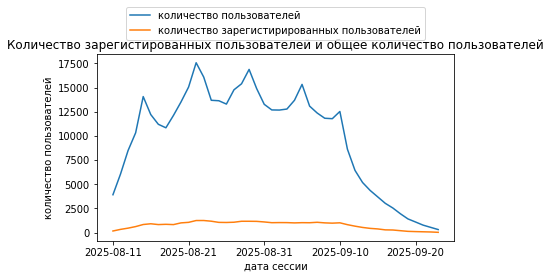

In [13]:
#Строим график
plt.figure(figsize=(10, 5))
d_hist_4.plot(
    kind='line',
    title='Количество зарегистированных пользователей и общее количество пользователей', 
    legend=True, 
    xlabel='дата сессии', 
    ylabel='количество пользователей'
    )
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=1) 
plt.tight_layout()

In [14]:
#Считаем долю
d_hist_4['share']=100*d_hist_4['количество зарегистирированных пользователей']/d_hist_4['количество пользователей']

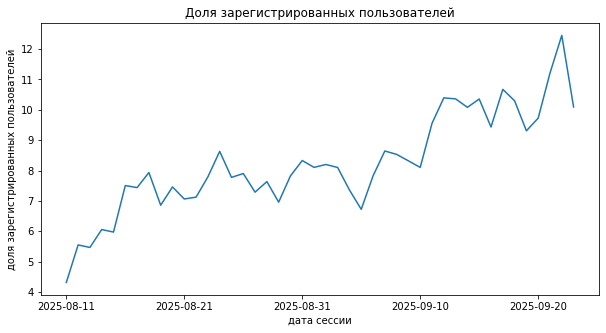

In [15]:
#Строим график
plt.figure(figsize=(10, 5))
d_hist_4['share'].plot(
    kind='line',
    title='Доля зарегистрированных пользователей', 
    legend=False, 
    xlabel='дата сессии', 
    ylabel='доля зарегистрированных пользователей'
    )
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [16]:
#Посчитаем количество первых сессий, reset_index ставим, чтобы всем столбцам были присвоены названия
d_hist_5=sessions_history[sessions_history['session_number']==1].groupby('page_counter')['session_id'].nunique().reset_index()

In [17]:
#Установим индекс
d_hist_5=d_hist_5.set_index('page_counter')

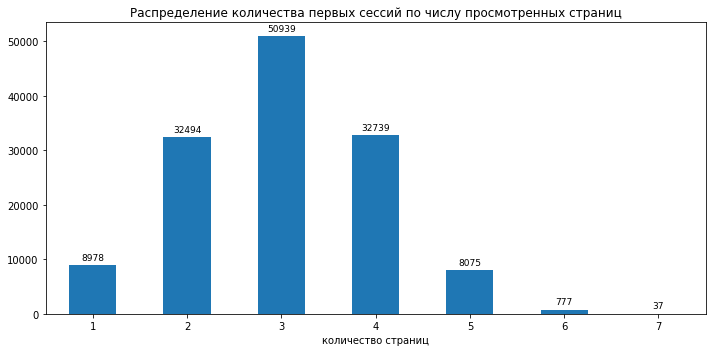

In [18]:
# Строим график и сохраняем объект осей в переменную ax
ax = d_hist_5.plot(
    kind='bar', 
    title='Распределение количества первых сессий по числу просмотренных страниц', 
    legend=False, 
    xlabel='количество страниц',
    rot=0, 
    figsize=(10, 5), 
    )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                      # Текст подписи (значение высоты)
        (p.get_x() + p.get_width() / 2., p.get_height()), # Координаты (x, y)
        ha='center',                                   # Центрирование по x
        va='bottom',                                   # Привязка снизу к тексту
        xytext=(0, 3),                                 # Смещение текста вверх на 3 пункта
        textcoords='offset points',                    # Тип смещения
        fontsize=9                                     # Размер шрифта
    )
plt.tight_layout()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [19]:
#Создаем столбец
sessions_history['good_session']=(sessions_history['page_counter'] >= 4).astype(int)

In [20]:
#Считаем долю
d_hist_6=100*sessions_history[sessions_history['session_number']==1].groupby('session_date')['good_session'].mean()

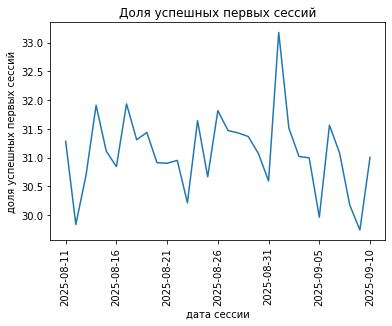

In [21]:
#Строим график
d_hist_6.plot(
    kind='line',
    title='Доля успешных первых сессий', 
    legend=False, 
    xlabel='дата сессии', 
    ylabel='доля успешных первых сессий'
    )
plt.xticks(rotation=90)
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [22]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03*p # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [23]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users =d_hist_4['количество пользователей'].sum()/sessions_history['session_date'].nunique()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2*sample_size/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [24]:
#Загрузим данные
sessions_test_part=pd.read_csv('/datasets/sessions_project_test_part.csv')

In [25]:
#Выведем данные
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [26]:
#Рассчитаем количество уникальных пользователей для каждой группы
test_1=sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index()

In [27]:
print(test_1)

  test_group  user_id
0          A     1477
1          B     1466


In [28]:
#Рассчитаем разность между группами
N_a=test_1[test_1['test_group']=='A']['user_id']
number_a=N_a.iloc[0]
N_b=test_1[test_1['test_group']=='B']['user_id']
number_b=N_b.iloc[0]
P=100*abs(number_a-number_b)/number_a
print(f"Рассчитанная разность между группами {P} %")                                                                                                

Рассчитанная разность между группами 0.7447528774542993 %


In [29]:
#установим индекс
test_1=test_1.set_index('test_group')

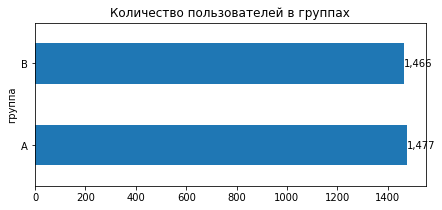

In [30]:
#Нарисуем график
ax = test_1.plot(
    kind='barh', 
    title='Количество пользователей в группах', 
    legend=False, 
    xlabel='группа',
    rot=0, 
    figsize=(7, 3), 
    )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [31]:
#Проверим пересечение пользователей
A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(A) & set(B))
print(intersection)

[]


In [32]:
#Второй способ
display(sessions_test_part.groupby('user_id')['test_group'].nunique().reset_index().sort_values(by='test_group', ascending=False))

,user_id,test_group
0,00079359B9D3C6F7,1
1955,ADC2E1E1158CFBB2,1
1957,ADCEEDAD20F4782F,1
1958,ADDCDDC883993FA6,1
1959,AE072C4F9B473BCD,1
...,...,...
983,54C3FA4C32B6ABBA,1
984,54F28A45A5E77DB8,1
985,54FF42B690A9B2E5,1
986,55529D5E3198D24D,1


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [33]:
#Распределение устройств по группе А
test_2=100*sessions_test_part[sessions_test_part['test_group']=='A'].groupby('device')['user_id'].nunique()/number_a

In [34]:
#Распределение устройств по группе B
test_3=100*sessions_test_part[sessions_test_part['test_group']=='B'].groupby('device')['user_id'].nunique()/number_b

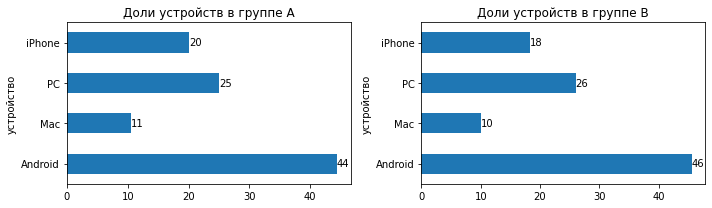

In [35]:
# Создаем фигуру с 1 строкой и 2 столбцами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3))

# Первая диаграмма (слева)
test_2.plot(
    kind='barh', 
    ax=ax1, # <--- указываем первую область
    title='Доли устройств в группе А', 
    legend=False,
    xlabel='устройство',
    rot=0, 
        )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax1.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax1.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
   

# Вторая диаграмма (справа)
# Замените 'grouped2' на данные для вашей второй диаграммы
test_3.plot(
    kind='barh', 
    ax=ax2, # <--- указываем первую область
    title='Доли устройств в группе B', 
    legend=False,
    xlabel='устройство',
    rot=0, 
        )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax2.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax2.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [36]:
#Распределение пользователей группы А по регионам
test_4=100*sessions_test_part[sessions_test_part['test_group']=='A'].groupby('region')['user_id'].nunique()/number_a

In [37]:
#Распределение пользователей группы B по регионам
test_5=100*sessions_test_part[sessions_test_part['test_group']=='B'].groupby('region')['user_id'].nunique()/number_b

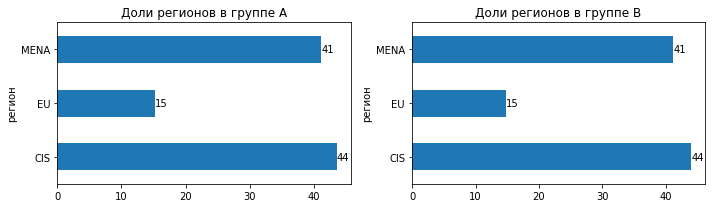

In [38]:
# Создаем фигуру с 1 строкой и 2 столбцами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3))

# Первая диаграмма (слева)
test_4.plot(
    kind='barh', 
    ax=ax1, # <--- указываем первую область
    title='Доли регионов в группе А', 
    legend=False,
    xlabel='регион',
    rot=0, 
        )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax1.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax1.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
    
# Вторая диаграмма (справа)
# Замените 'grouped2' на данные для вашей второй диаграммы
test_5.plot(
    kind='barh', 
    ax=ax2, # <--- указываем первую область
    title='Доли регионов в группе B', 
    legend=False,
    xlabel='регион',
    rot=0, 
        )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax2.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax2.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Различие количества пользователей в группах по итогам одного дня теста составило 0.74% Выборки являются независимыми, пересечения пользователей не обнаружено Сохраняется примерно одинаковое распределение пользователей тестовой и контрольной групп по устройствам и регионам. A/B-тест в первый день проходит корректно.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [39]:
#Загружаем файл
sessions_test=pd.read_csv('/datasets/sessions_project_test.csv')

In [40]:
#Вводим новый столбец
sessions_test['good_session']=(sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

В качестве целевой метрики можно взять среднее количество просмотренных страниц пользователем за сессию, тогда нулевая гипотеза - количество просмотренных страниц в группе А и В равно, альтернативная - количество просмотренных страниц в группе B больше, чем в группе А, то есть новый алгоритм рекомендаций увеличил среднее количество просмотренных страниц. Также можно взять метрику - доля успешных первых сессий, тогда нулевая гипотеза - доля успешных сессий равна в группе А и В, альтернативная - доля просмотренных страниц больше в группе B. В качестве прокси-метрик можно взять число активных пользователей, долю зарегистирированных пользователей, в качестве барьерной метрики - число сбоев при работе сайта.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [41]:
#количество успешных сессий в группе А
m_a=sessions_test[(sessions_test['session_number']==1)&(sessions_test['test_group']=='A')]['good_session'].sum()

In [42]:
#Количество сессий в группе А
n_a=sessions_test[(sessions_test['session_number']==1)&(sessions_test['test_group']=='A')]['good_session'].count()

In [43]:
#Доля в группе А
p_a=m_a/n_a

In [44]:
#количество успешных сессий в группе B
m_b=sessions_test[(sessions_test['session_number']==1)&(sessions_test['test_group']=='B')]['good_session'].sum()

In [45]:
#Количество сессий в группе B
n_b=sessions_test[(sessions_test['session_number']==1)&(sessions_test['test_group']=='B')]['good_session'].count()

In [46]:
#Доля в группе B
p_b=m_b/n_b

In [47]:
print(f'доля успешных сессий в группе А равна {p_a}, в группе В {p_b}, разница {p_b-p_a}')

доля успешных сессий в группе А равна 0.31572351932462733, в группе В 0.3146730669434354, разница -0.0010504523811919464


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [48]:
#Проверяем достаточность размера выборки
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # Проверьте предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # Установите уровень значимости


stat_ztest, p_value_ztest = proportions_ztest (# Проводим Z-тест пропорций
     [m_a, m_b],
     [n_a, n_b],
     alternative='smaller'
)

print(f'pvalue={p_value_ztest}') # Выводим полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.5783523649187868
Нулевая гипотеза находит подтверждение!


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

In [49]:
#Рассчитаем количество задействованных пользователей и длительность эксперимента
user_a=sessions_test[(sessions_test['test_group']=='A')]['user_id'].nunique()
user_b=sessions_test[(sessions_test['test_group']=='B')]['user_id'].nunique()
sessions_test['session_date'] = pd.to_datetime(sessions_test['session_date']).dt.date
duration=(sessions_test['session_date'].max()-sessions_test['session_date'].min()).days

In [50]:
print(f'В тесте приняли участие в группе А {user_a} пользователей, в группе B {user_b}, продолжительность эксперимента {duration} дней')

В тесте приняли участие в группе А 15163 пользователей, в группе B 15416, продолжительность эксперимента 19 дней


In [51]:
print(f'доля успешных сессий в группе А равна {p_a}, в группе В {p_b}, разница {p_b-p_a}, то есть нововведение привело к падению доли')

доля успешных сессий в группе А равна 0.31572351932462733, в группе В 0.3146730669434354, разница -0.0010504523811919464, то есть нововведение привело к падению доли


In [52]:
print(f'pvalue={p_value_ztest}, нулевая гипотеза находит подтверждение')

pvalue=0.5783523649187868, нулевая гипотеза находит подтверждение


Нововведение не стоит принимать, статистически значимого роста доли успешных первых сессий по результатам экперимента нет.